In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

<Axes: >

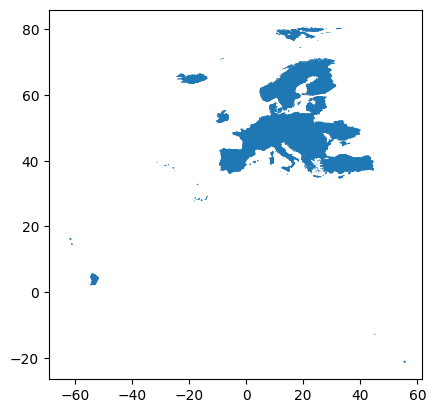

In [2]:
nuts_2024 = gpd.read_file('NUTS_RG_03M_2024_4326.geojson')
nuts_2024.plot()

<Axes: >

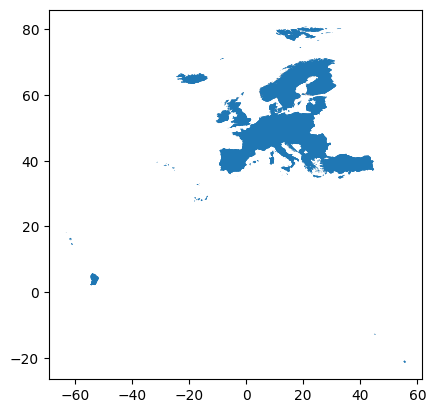

In [3]:
nuts_2021 = gpd.read_file('NUTS_RG_03M_2021_4326.geojson')
nuts_2021.plot()

<Axes: >

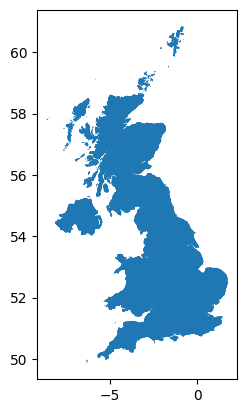

In [4]:
# Extract NUTS-UK regions from NUTS 2021 geojson
nuts_uk = nuts_2021[nuts_2021['CNTR_CODE'] == 'UK']

nuts_uk.to_file('nuts_uk.geojson', driver='GeoJSON')

nuts_uk = gpd.read_file('nuts_uk.geojson')
nuts_uk.plot()

<Axes: >

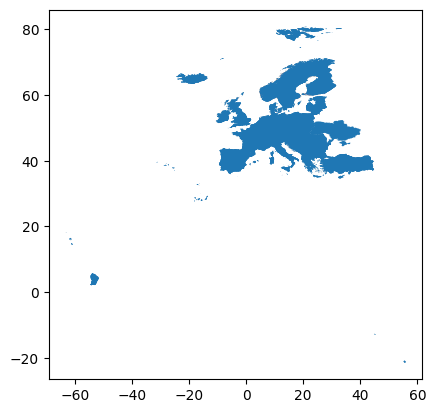

In [5]:
# Update NUTS 2024 regions with NUTS-UK regions 
merged = pd.concat([nuts_2024, nuts_uk], ignore_index=True)
merged.to_file("nuts_updated_uk.geojson", driver="GeoJSON")

nuts_updated = gpd.read_file('nuts_updated_uk.geojson')
nuts_updated.plot()

<Axes: >

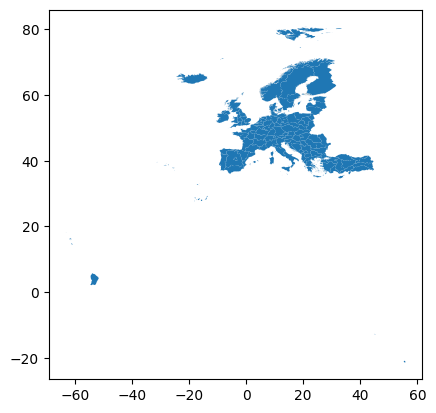

In [6]:
nuts1_updated_uk = nuts_updated[nuts_updated['LEVL_CODE'] == 1]

nuts1_updated_uk.to_file('nuts1_updated_uk_regions.geojson', driver='GeoJSON')

nuts1_updated_uk = gpd.read_file('nuts1_updated_uk_regions.geojson')
nuts1_updated_uk.plot()

<Axes: >

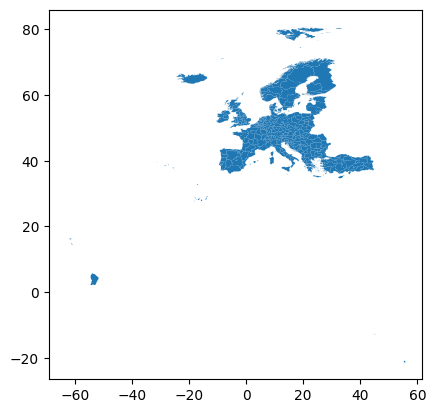

In [7]:
nuts2_updated_uk = nuts_updated[nuts_updated['LEVL_CODE'] == 2]

nuts2_updated_uk.to_file('nuts2_updated_uk_regions.geojson', driver='GeoJSON')

nuts2_updated_uk = gpd.read_file('nuts2_updated_uk_regions.geojson')
nuts2_updated_uk.plot()

<Axes: >

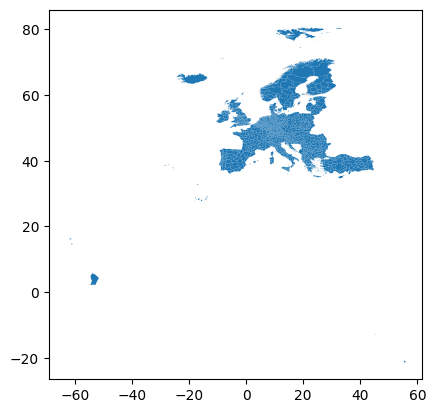

In [8]:
nuts3_updated_uk = nuts_updated[nuts_updated['LEVL_CODE'] == 3]

nuts3_updated_uk.to_file('nuts3_updated_uk_regions.geojson', driver='GeoJSON')

nuts3_updated_uk = gpd.read_file('nuts3_updated_uk_regions.geojson')
nuts3_updated_uk.plot()

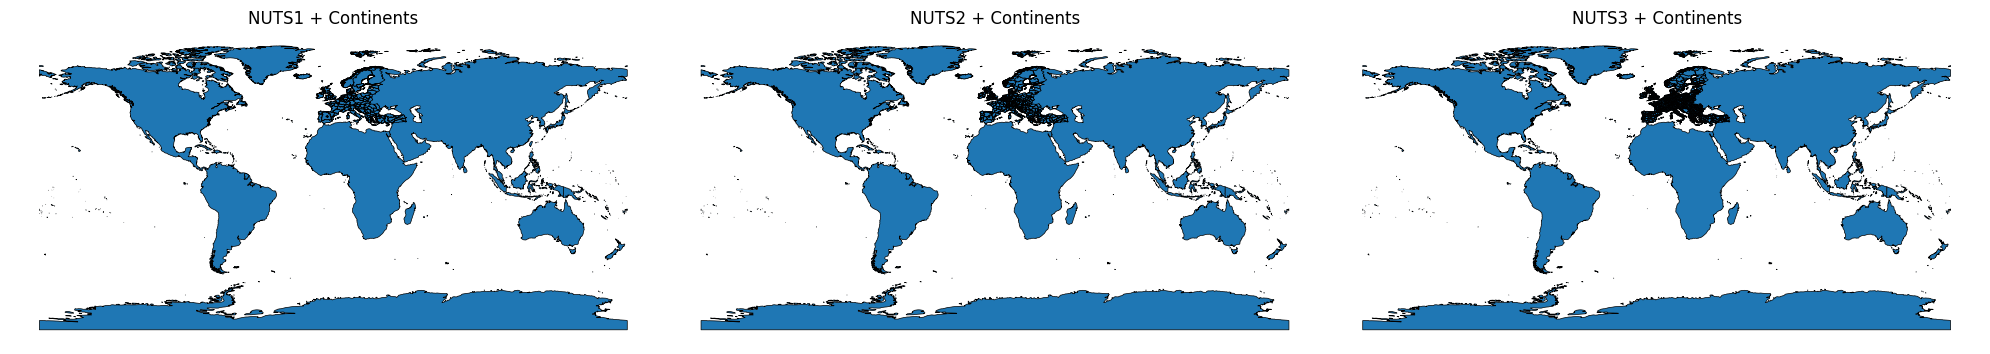

In [5]:
# Load continents base layer
continents_json = gpd.read_file('utils/continents.geojson')

# NUTS1: Merge continents + NUTS1 regions
nuts1_json = gpd.read_file('nuts1_updated_uk_regions.geojson')
nuts1_json = nuts1_json.to_crs(continents_json.crs)
cont_nuts1 = pd.concat([continents_json, nuts1_json], ignore_index=True)
cont_nuts1.to_file("NUTS1_regions_(2024 edition).geojson", driver='GeoJSON')

# NUTS2: Merge continents + NUTS2 regions  
nuts2_json = gpd.read_file('nuts2_updated_uk_regions.geojson')
nuts2_json = nuts2_json.to_crs(continents_json.crs)
cont_nuts2 = pd.concat([continents_json, nuts2_json], ignore_index=True)
cont_nuts2.to_file("NUTS2_regions_(2024 edition).geojson", driver='GeoJSON')

# NUTS3: Merge continents + NUTS3 regions
nuts3_json = gpd.read_file('nuts3_updated_uk_regions.geojson')
nuts3_json = nuts3_json.to_crs(continents_json.crs)
cont_nuts3 = pd.concat([continents_json, nuts3_json], ignore_index=True)
cont_nuts3.to_file("NUTS3_regions_(2024 edition).geojson", driver='GeoJSON')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
gpd.read_file('NUTS1_regions_(2024 edition).geojson').plot(ax=axes[0], 
    edgecolor='black', linewidth=0.5).set_axis_off()
axes[0].set_title('NUTS1 + Continents')
gpd.read_file('NUTS2_regions_(2024 edition).geojson').plot(ax=axes[1], 
    edgecolor='black', linewidth=0.5).set_axis_off()
axes[1].set_title('NUTS2 + Continents')
gpd.read_file('NUTS3_regions_(2024 edition).geojson').plot(ax=axes[2], 
    edgecolor='black', linewidth=0.5).set_axis_off()
axes[2].set_title('NUTS3 + Continents')
plt.tight_layout()
plt.show()